# Price and Demand Functions

### Abstract

Objective  - Price Optimization without assuming demand shape


Price optimization is applied (tested) on three exemplary demand functions
* linear demand
* constant elasticity demand
* logit demand

Price optimization functions
* log_quadratic
* log_linear

General Findings


### Organization of this notebook
* Notebook setup
* Demand parameters
* Demand curves
* Demand samples
* Elasticity vs. Inverse Unit Margin
* Demand Fit Theory
* MAB Loop: Optimum Demand, Price, Profit
* Evaluate MAB Results

# Notebook Setup

In [5]:
!python --version

Python 3.12.7


In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "py_modules"))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import beautifulplots as bp


from demand_elasticity_profit import (
    demand_constant_elasticity, 
    demand_linear, elasticity_linear,
    demand_logit, elasticity_logit,
    get_vhat_invumar_df,
)

from utils_probability import demand_sample

# Demand Parameters

Business Parameters

These parameters are contexttual to the business problem and are necessary to model demand behavior.
* CV - coefficient of variation. Represents the demand variation relative to the mean, $CV = \sigma/\mu$
* c - cost per unit.
* F - fixed cost.

Below (code cell), we use the term `sigma_log` because the standard deviation corresponds to the log domain corresponding to log D demand variations - additive in the log domain (log scale) and multiplicative in the linear domain  (.e., demand with multiplicative "noisy" variation). This is the typical representation for market demand situations. This $sigma_log$ is often simply termed $\sigma$ in the literature, however both represent stadnard-deviation in the log domain.

In [7]:
# Demand General Parameters
CV =0.2 
v = 1.8
c = 1.2
F = 6

print(f'CV = {CV}, Coefficient of Variation')
print(f'v = {1.8}, elasticity')
print(f'c = {c}, variable costs')
print(f'F = {F}, Fixed costs')


CV = 0.2, Coefficient of Variation
v = 1.8, elasticity
c = 1.2, variable costs
F = 6, Fixed costs


Additonal price parameters
*  p0, is the currently set market price, though it is not optimal.
*  price_min - minimum price guard rail
*  price_max - maximum price guard rail

In [8]:
p0 = 3.6
price_min = 2
price_max = 4.0
print(f'p0 = {p0}, initial price')
print(f'price_min = {price_min}, minimum price')
print(f'price_max = {price_max}, maximum price')

p0 = 3.6, initial price
price_min = 2, minimum price
price_max = 4.0, maximum price


For exemplary purposes, we set the following objectives across the demand functions
1. Profit optimizing price, p_opt, is the same across all the demand functions 
2. Demand, d(p_opt) is the same for all three demand examples.
3. Elasticity at p_opt, is the same for all demand examples.

Demand parameters for the three demand functions - constant elasticity, linear demand, logit demand

We begin with constant elasticity, because it provides conceptual understanding of elasticity. Then, we will set the parameters for the other demand functions to aligned with the profit optimizing price, p_opt, and corresponding elasticity.

In [9]:
# Demand Parameters

#### Constant Elasticity Demand ###
v = 1.8
p_opt = (v / (v - 1)) * c
A_ce = 4000
D_opt = A_ce * p_opt **(-v)
Profit_opt = p_opt * D_opt - c * D_opt - F  

#### linear demand ####
#  - match the slope of the constant elasticity demand at p_opt
#  d_linear = A ( 1 - bp )
#  p_zero = A / b
#  d_linear(p_opt) = d_ce(p_opt)
#  A (1 - b * p_opt) = A * p_opt **(-v)
#  A is known, solve for b
b_linear = v / (( 1 + v) * p_opt)
A_linear = D_opt / (1 - b_linear * p_opt) # A = d(p_opt) / (1 - b * p_opt)

###### Logit #######
# need to solve for a and b
# constraints:
#  1) v_logit(p_opt) =  v = 1.8
#  2) pmid = p_opt
#  b_logit = 2 * v / p_opt ... 
#  a_logit = b_logit * p_opt ... sets the midpoint for logit demand
b_logit =  2 * v / p_opt
a_logit =  b_logit * p_opt
A_logit = 2 * D_opt # Logit demand is A/2 at p_opt

# Constant Elasticity Demand
print('Connstant Elasticity Demand')
print(f'  p_opt = {p_opt}')
print(f'  D_opt = {D_opt}')
print(f'  v = {v}')
print(f'  A_ce = {A_ce}')
print(f'  Profit_opt = {Profit_opt}')

# Linear Demand
print()
print('Linear Demand')
print(f'  A_linear = {A_linear}')
print(f'  b_linear = {b_linear}')

# Logit De`mand
print()
print("Logit Demand")
print(f'  A_logit = {A_logit}')
print(f'  b_logit = {b_logit}')
print(f'  a_logit = {a_logit}')


Connstant Elasticity Demand
  p_opt = 2.6999999999999997
  D_opt = 669.2759448378242
  v = 1.8
  A_ce = 4000
  Profit_opt = 997.9139172567361

Linear Demand
  A_linear = 1873.972645545908
  b_linear = 0.23809523809523814

Logit Demand
  A_logit = 1338.5518896756485
  b_logit = 1.3333333333333335
  a_logit = 3.6


# Revenue Profit Costs

In [10]:
Profit_opt = (p_opt -c) * D_opt -  F

R_opt = p_opt * D_opt

MC = c # marginal cost

TC_p_opt = c * D_opt + F
TCPU_p_opt = TC_p_opt / D_opt

RPU_D_opt = R_opt / D_opt
Profit_opt

print(f'Profit_opt = {Profit_opt}')

Profit_opt = 997.9139172567362


# Demand Curves

Demand Curves
* ***Linear demand*** - introductory, examplary, easy to understand, though unrealistic. Demand varies linearly with price. 
* ***Constant elasticity demand*** - Useful for exemplary purposes, though unrealistic. Elasticity is constant resulting in an exponential demand function, with a constant multiplier, which establishes the market size, while the exponential elasticity defines the demand to price behavior.
* ***Logit Demand*** - a tractable, semi-realistic, demand function. Models human behavior, wherein customers tend to buy when price is low, and do not buy when price is too low.

In [11]:
D_p1 = demand_linear(p0, A_linear, b_linear, sigma_log=0)

In [12]:
# Demad Functions and Dataframes

Nsamples = 100

# linear demand
# 1/b_linear is the price at which demand is zero.
p_linear= np.linspace(.01, 1/b_linear, Nsamples)
d_linear = demand_linear(p_linear, A_linear, b_linear, sigma_log=0)
v_linear = elasticity_linear(p_linear, A_linear, b_linear)
df_demand_linear = pd.DataFrame({'price': p_linear, 'demand': d_linear, "v": v_linear })

# constant elasticity demand
p_ce = np.linspace(1, 10, Nsamples)
d_ce = demand_constant_elasticity(p_ce, A_ce, v, sigma_log = 0, size=Nsamples)
df_demand_constant_elasticity = pd.DataFrame({'price': p_ce, 'demand':d_ce })

# logit demand
p_logit = np.linspace(1, 10, Nsamples)
d_logit = demand_logit(p_logit, A_logit, a_logit, b_logit, sigma_log=0)
v_logit = elasticity_logit(p_logit, a_logit, b_logit)
df_demand_logit = pd.DataFrame({'price': p_logit, 'demand': d_logit, "v":v_logit})

elasticity_linear: unstable/undefined at 1 value(s) (regularization_mode=regularized). prices=[4.2]


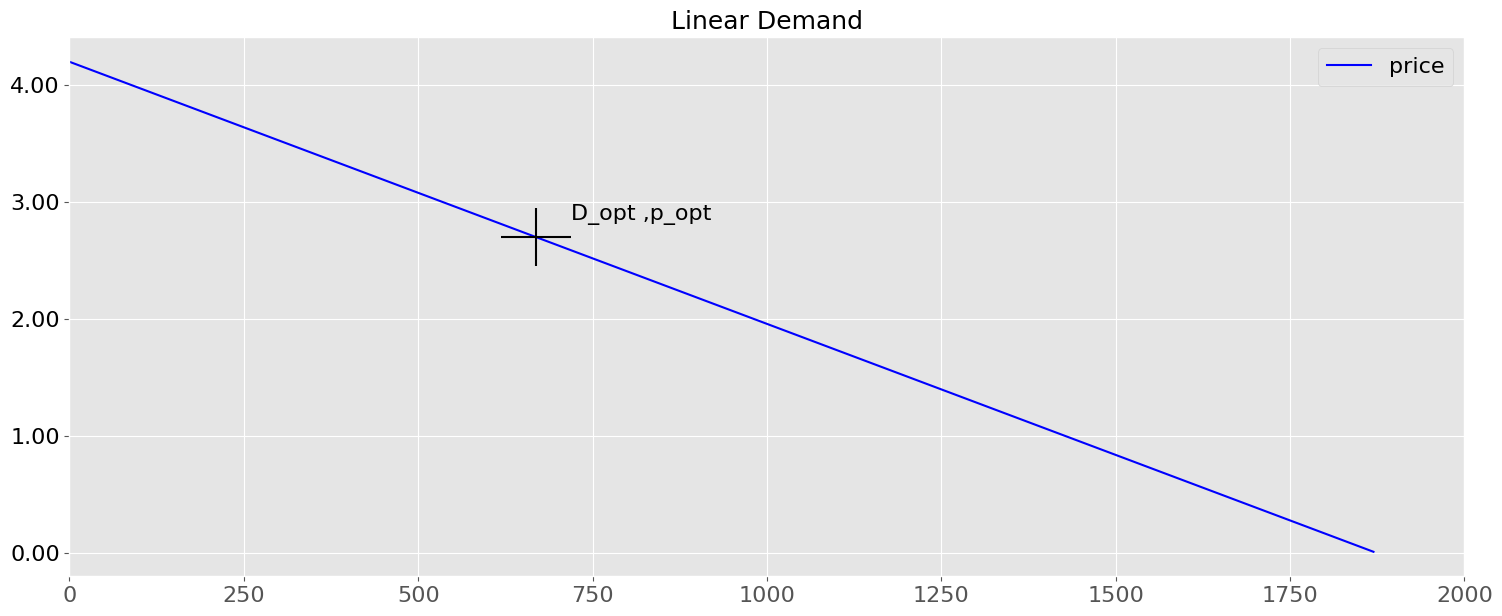

In [13]:
# Graph Linear Demand

plt.style.use("ggplot")
fig, axs = plt.subplots(nrows=1,ncols=1, figsize=(18,7))

bp.lineplot(df_demand_linear, x='demand', color='blue', y='price', title="Linear Demand", annotate = [("D_opt ,p_opt",(D_opt+50, p_opt+.15))] ,x_lims=(0, 2000), ax=axs)


plt.hlines(y=p_opt, xmin=D_opt-50, xmax=D_opt+50, color='black', linestyle='-')
plt.vlines(x=D_opt, ymin=p_opt-.25, ymax=p_opt+.25, color='black', linestyle='-')

plt.show()

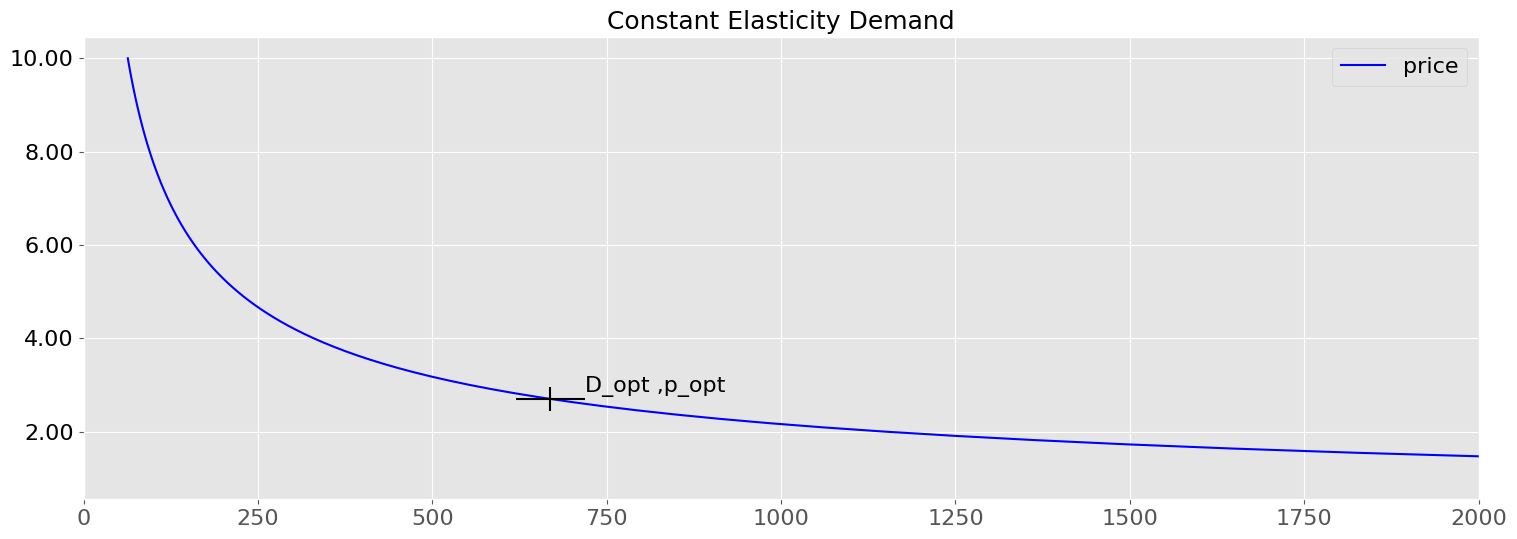

In [14]:
# Constant Elasticity Demand Graph

fig, axs = plt.subplots(nrows=1,ncols=1, figsize=(18,6))

bp.lineplot(df_demand_constant_elasticity, x='demand', y='price', title="Constant Elasticity Demand", annotate = [("D_opt ,p_opt",(D_opt+50, p_opt+.15))] ,    x_lims=(0, 2000), color='blue',  ax=axs)


plt.hlines(y=p_opt, xmin=D_opt-50, xmax=D_opt+50, color='black', linestyle='-')
plt.vlines(x=D_opt, ymin=p_opt-.25, ymax=p_opt+.25, color='black', linestyle='-')

plt.show()

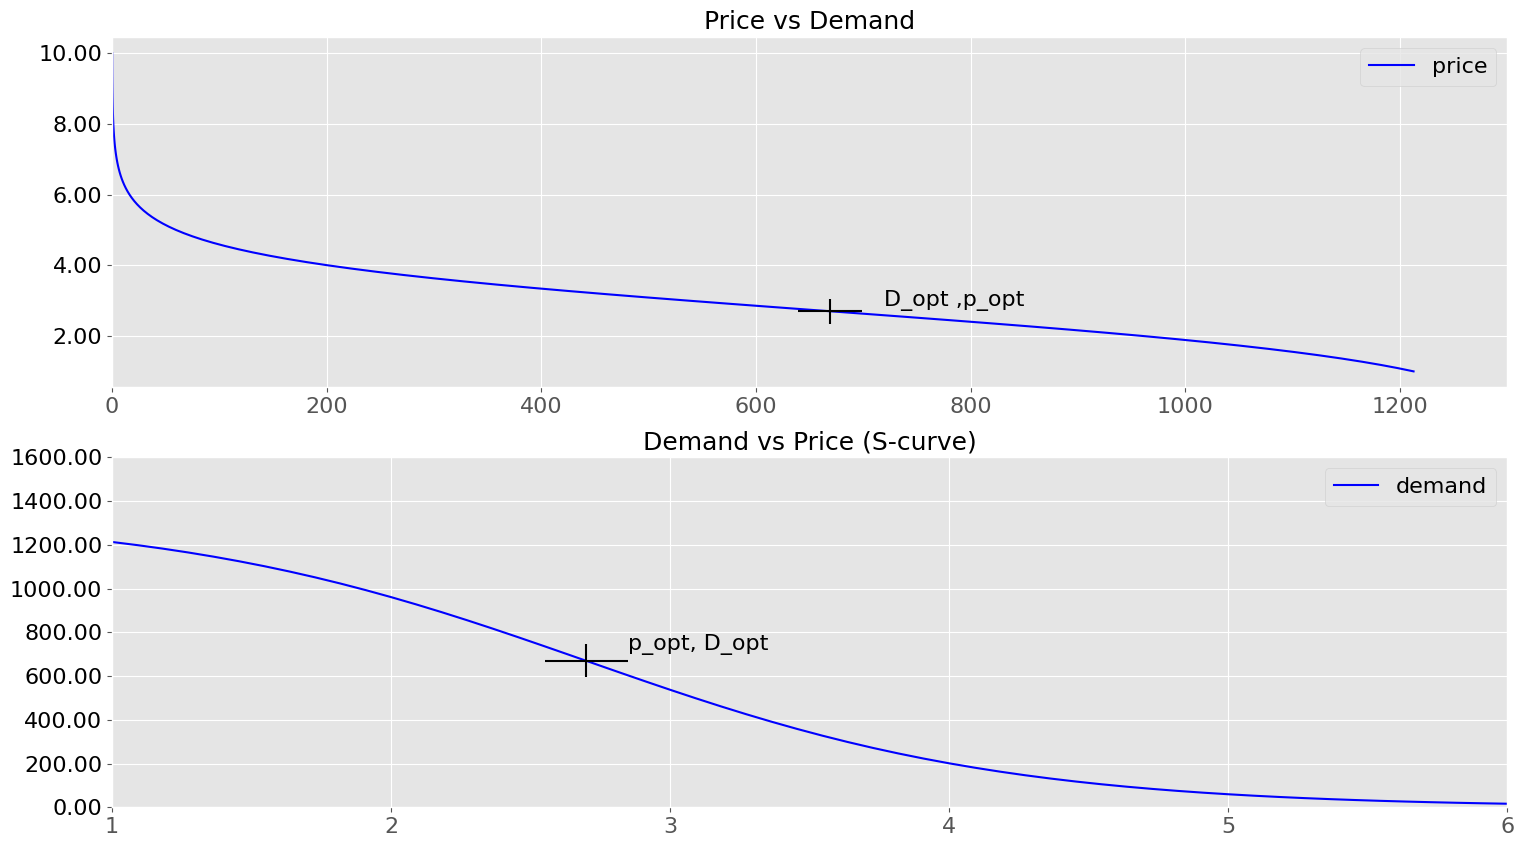

In [15]:
# Logit Demand Graph

fig, axs = plt.subplots(nrows=2,ncols=1, figsize=(18,10))

# price vs. demand .... proto-typical economics graph
bp.lineplot(df_demand_logit, x='demand', y='price', color = 'blue', title='Price vs Demand', annotate = [("D_opt ,p_opt",(D_opt+50, p_opt+.15))], x_lims=(0,1300), ax = axs[0])
        
axs[0].hlines(y=p_opt, xmin=D_opt-30, xmax=D_opt+30, color='black', linestyle='-')
axs[0].vlines(x=D_opt, ymin=p_opt-.35, ymax=p_opt+.35, color='black', linestyle='-')


# demand vs price S-shaped
bp.lineplot(df_demand_logit, y='demand', x='price', color = 'blue', title='Demand vs Price (S-curve)', annotate = [("p_opt, D_opt",( p_opt+.15, D_opt+50))],y_lims=(0,1600), x_lims = (1,6), ax = axs[1] )

axs[1].hlines(y=D_opt, xmin=p_opt-.15, xmax=p_opt+.15, color='black', linestyle='-')
axs[1].vlines(x=p_opt, ymin=D_opt-75, ymax=D_opt+75, color='black', linestyle='-')


plt.show()


# Demand Samples

Additional Parameters
D_p0
D_opt_lin  
D_opt_logit  

In [16]:
# Demand General Parameters

sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)

# Deterministic constant-elasticity demand at p1 (no demand variation noise)
D_p0_ce = float(demand_constant_elasticity(p0, A_ce, v, sigma_log=0, size=1)[0])

D_p0_lin = float(demand_linear(p0, A_linear, b_linear, sigma_log=0, size=1)[0])

D_p0_logit = float(demand_logit(p0, A_logit, a_logit, b_logit, sigma_log=0, size=1)[0])


print(f'sigma_log = {sigma_log}')
print(f'D_p0_ce = {D_p0_ce}, ... median of the lognormal distribution')
print(f'D_p0_lin = {D_p0_lin}, ... median of the lognormal distribution')
print(f'D_p0_logit = {D_p0_logit}, ... median of the lognormal distribution')

sigma_log = 0.19804220043536505
D_p0_ce = 398.76358331963996, ... median of the lognormal distribution
D_p0_lin = 267.71037793512943, ... median of the lognormal distribution
D_p0_logit = 309.8415884604696, ... median of the lognormal distribution


Constant Elasticity Demand Samples

In [17]:
# constant elasticity demand
N_demand_samples = 300

# Demand samples at p_opt with multiplicative log-normal variation
y_p_opt_ce = demand_constant_elasticity( p=p_opt,A=A_ce,  v=v, sigma_log=sigma_log, size=N_demand_samples )
df_y_p_opt_samples_ce = pd.DataFrame({'y_p_opt': y_p_opt_ce, 'p_opt': p_opt})
df_y_p_opt_samples_ce["i"] = range(len(df_y_p_opt_samples_ce))

y_p0_ce = demand_constant_elasticity( p=p0,A=A_ce,  v=v, sigma_log=sigma_log, size=N_demand_samples )
df_y_p0_samples_ce = pd.DataFrame({'y_p0': y_p0_ce, 'p0': p0})
df_y_p0_samples_ce["i"] = range(len(df_y_p0_samples_ce))


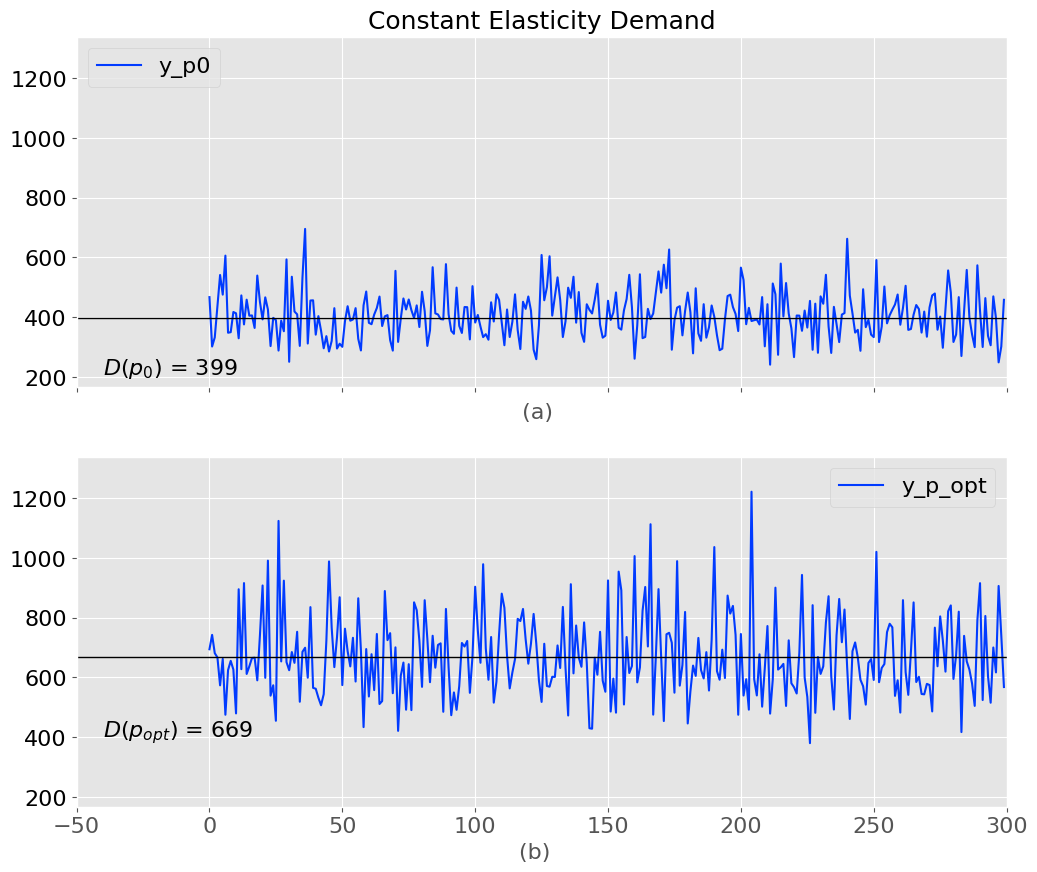

In [18]:
# graph constnat elasticity demand samples
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12,10))
#df_y_samples["y_p0"] = df_y_samples["y_p1"]

bp.lineplot(df_y_p0_samples_ce,x = "i", y='y_p0', title='Constant Elasticity Demand', xlabel='Demand',
            x_axis_label = """ (a)  """ ,y_axis_format=".0f", color='#013BFF', h_line=D_p0_ce, y_lims = (D_opt-.75*D_opt,D_opt+D_opt), x_lims=(-50,N_demand_samples),
            legend_loc = "upper left",
         annotate=[(f"$D(p_0)$ = {round(D_p0_ce)}",(-40,210))],
         ax = axs[0] )
axs[0].set_xticklabels([])
#axs[0].get_legend().set_visible(False)

bp.lineplot(df_y_p_opt_samples_ce,x = "i", y=f'y_p_opt',  xlabel='Demand',y_axis_format=".0f", 
        x_axis_label =  """(b)  """,
        color='#013BFF', h_line=D_opt, y_lims = (D_opt-.75*D_opt,D_opt+D_opt),  x_lims=(-50,N_demand_samples),
        annotate=[("$D(p_{opt})$ = "+ f'{round(D_opt)}',(-40,400))],
        ax = axs[1] )

plt.subplots_adjust(hspace=.2, wspace=0.1)
plt.show()

Linear Demand Samples

In [19]:
# linear demand samples

# Demand samples at p_opt with multiplicative log-normal variation
y_p_opt_lin = demand_linear( p=p_opt,A=A_linear,  b=b_linear, sigma_log=sigma_log, size=N_demand_samples )
df_y_p_opt_samples_lin = pd.DataFrame({'y_p_opt': y_p_opt_lin, 'p_opt': p_opt})
df_y_p_opt_samples_lin["i"] = range(len(df_y_p_opt_samples_lin))

y_p0_lin = demand_linear( p=p0,A=A_linear, b=b_linear, sigma_log=sigma_log, size=N_demand_samples )
df_y_p0_samples_lin = pd.DataFrame({'y_p0': y_p0_lin, 'p1': p0})
df_y_p0_samples_lin["i"] = range(len(df_y_p0_samples_lin))

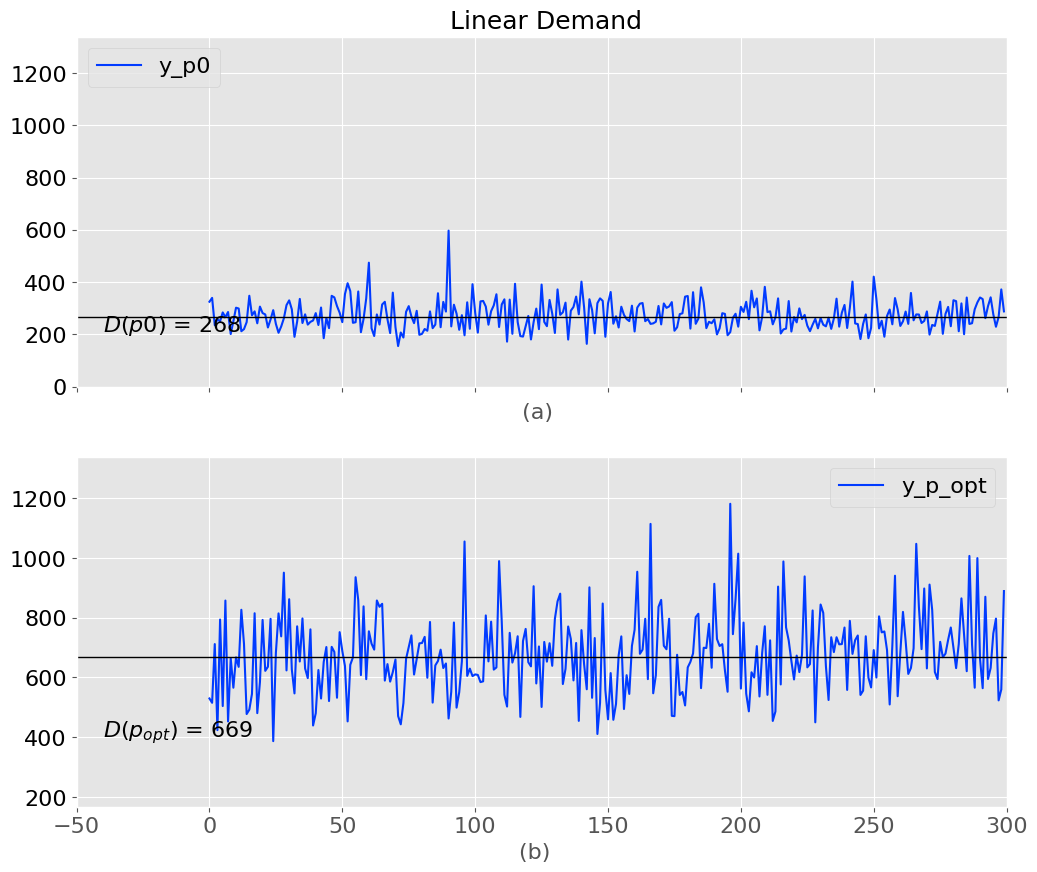

In [20]:
# graph linear demand samples
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12,10))
#df_y_samples["y_p0"] = df_y_samples["y_p1"]

bp.lineplot(df_y_p0_samples_lin,x = "i", y='y_p0', title=' Linear Demand', xlabel='Demand',
            x_axis_label = """ (a)  """ ,y_axis_format=".0f", color='#013BFF', h_line=D_p0_lin, y_lims = (D_opt-1*D_opt,D_opt+D_opt), x_lims=(-50,N_demand_samples),
            legend_loc = "upper left",
         annotate=[(f"$D(p0)$ = {round(D_p0_lin)}",(-40,210))],
         ax = axs[0] )
axs[0].set_xticklabels([])
#axs[0].get_legend().set_visible(False)

bp.lineplot(df_y_p_opt_samples_lin,x = "i", y=f'y_p_opt',  xlabel='Demand',y_axis_format=".0f", 
        x_axis_label =  """(b)  """,
        color='#013BFF', h_line=D_opt, y_lims = (D_opt-.75*D_opt,D_opt+D_opt),  x_lims=(-50,N_demand_samples),
        annotate=[("$D(p_{opt})$ = "+ f'{round(D_opt)}',(-40,400))],
        ax = axs[1] )

plt.subplots_adjust(hspace=.2, wspace=0.1)
plt.show()



Logit demand samples

In [21]:
# logit demand samples

# Demand samples at p_opt with multiplicative log-normal variation
y_p_opt_logit = demand_logit( p=p_opt,A=A_logit, a=a_logit, b=b_logit, sigma_log=sigma_log, size=N_demand_samples )
df_y_p_opt_samples_logit = pd.DataFrame({'y_p_opt': y_p_opt_logit, 'p_opt': p_opt})
df_y_p_opt_samples_logit["i"] = range(len(df_y_p_opt_samples_logit))

y_p0_logit = demand_logit( p=p0,A=A_logit, a=a_logit,b=b_logit, sigma_log=sigma_log, size=N_demand_samples )
df_y_p0_samples_logit = pd.DataFrame({'y_p0': y_p0_logit, 'p0': p0})
df_y_p0_samples_logit["i"] = range(len(df_y_p0_samples_logit))

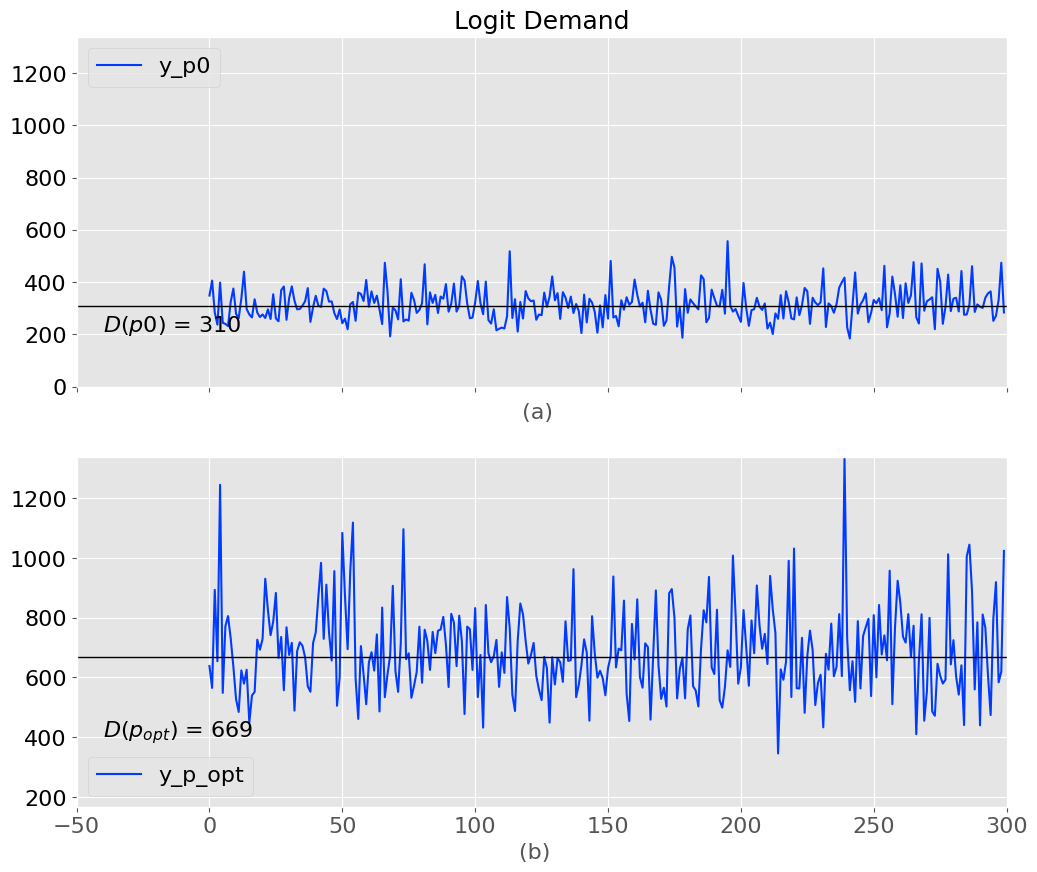

In [22]:
# graph logit demand samples
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12,10))
#df_y_samples["y_p0"] = df_y_samples["y_p1"]

bp.lineplot(df_y_p0_samples_logit,x = "i", y='y_p0', title='Logit Demand', xlabel='Demand',
            x_axis_label = """ (a)  """ ,y_axis_format=".0f", color='#013BFF', h_line=D_p0_logit, y_lims = (D_opt-1*D_opt,D_opt+D_opt), x_lims=(-50,N_demand_samples),
            legend_loc = "upper left",
         annotate=[(f"$D(p0)$ = {round(D_p0_logit)}",(-40,210))],
         ax = axs[0] )
axs[0].set_xticklabels([])
#axs[0].get_legend().set_visible(False)

bp.lineplot(df_y_p_opt_samples_logit,x = "i", y=f'y_p_opt',  xlabel='Demand',y_axis_format=".0f", 
        x_axis_label =  """(b)  """,
        color='#013BFF', h_line=D_opt, y_lims = (D_opt-.75*D_opt,D_opt+D_opt),  x_lims=(-50,N_demand_samples),
        annotate=[("$D(p_{opt})$ = "+ f'{round(D_opt)}',(-40,400))],
        ax = axs[1] )

plt.subplots_adjust(hspace=.2, wspace=0.1)
plt.show()

# Elasticity vs. Inverse Unit Margin

Now we evaluate elasticity estimate, $\hat v$ and compare it to inverse unit margin = $p/p-c$

Phillips, Equation 5.7 the elasticity estimate is equal to the inverse unit margin at the profit optimizaing price. A numerical complication, in computing this property, is that practically implemenations are based on finite differences, which can lead to innacuracies. Thus, some care is taken to ensure accuracy, as follows.

* The price change is between two endpoints, p and p + delta = p_delta.
* The corresponding inverse unit margin is best associated with the midpoint of these two endpoints
* p_mid = sqrt(p1 * p2) ... geometric demand linear space, ... arithmetic in log space

Estimating elasticity vhat ($\hat v$)
* Elasticity, v =  % change demand  /  % change price, 
* Point elasticity is given by the the (p/d) dd / dp 
* v(p) = - (dd / d ) /( dp / p ) = - p/d * dd/dp
* dd / d  = d log d $ \approx  \Delta log \ d$ 
* dp / p  = d log p $ \approx \Delta log \ p $
* $\hat v \approx \Delta log d / \Delta log p $
* $\hat v (arc \ elasticity) \approx  - (log \, d2 - log \ d1) / ( log \ p2 - log \  p1 ) $


demand type = constant_elasticity
demand_params = {'A': 4000, 'v': 1.8}


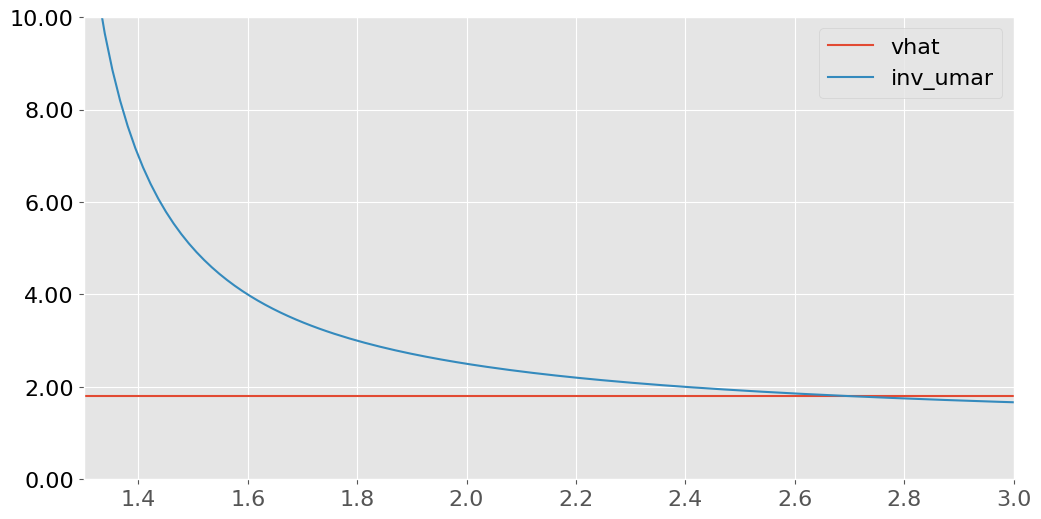

df_demand_ce.head()


,p_mid,p,delta,p_delta,d,d_delta,vhat,inv_umar,diff_vhat_inv_umar,demand_type
0,1.226965,1.220000,0.01397,1.233970,2796.483725,2739.755481,1.8,45.502062,-43.702062,constant_elasticity
1,1.240935,1.233970,0.01397,1.247940,2739.755481,2684.797351,1.8,30.314684,-28.514684,constant_elasticity
2,1.254905,1.247940,0.01397,1.261910,2684.797351,2631.535202,1.8,22.855860,-21.055860,constant_elasticity
3,1.268875,1.261910,0.01397,1.275879,2631.535202,2579.898781,1.8,18.422805,-16.622805,constant_elasticity
4,1.282845,1.275879,0.01397,1.289849,2579.898781,2529.821468,1.8,15.484828,-13.684828,constant_elasticity


Target price: 2.7
Closest index: 105


,p_mid,p,delta,p_delta,d,d_delta,vhat,inv_umar,diff_vhat_inv_umar,demand_type
100,2.623961,2.616985,0.01397,2.630955,707.974791,701.222597,1.8,1.842720,-0.042720,constant_elasticity
101,2.637930,2.630955,0.01397,2.644925,701.222597,694.570049,1.8,1.834533,-0.034533,constant_elasticity
102,2.651900,2.644925,0.01397,2.658894,694.570049,688.015162,1.8,1.826503,-0.026503,constant_elasticity
103,2.665870,2.658894,0.01397,2.672864,688.015162,681.556001,1.8,1.818626,-0.018626,constant_elasticity
104,2.679840,2.672864,0.01397,2.686834,681.556001,675.190679,1.8,1.810898,-0.010898,constant_elasticity
105,2.693810,2.686834,0.01397,2.700804,675.190679,668.917353,1.8,1.803315,-0.003315,constant_elasticity
106,2.707780,2.700804,0.01397,2.714774,668.917353,662.734231,1.8,1.795872,0.004128,constant_elasticity
107,2.721750,2.714774,0.01397,2.728744,662.734231,656.639559,1.8,1.788566,0.011434,constant_elasticity
108,2.735720,2.728744,0.01397,2.742714,656.639559,650.631630,1.8,1.781393,0.018607,constant_elasticity
109,2.749690,2.742714,0.01397,2.756683,650.631630,644.708777,1.8,1.774349,0.025651,constant_elasticity


In [23]:
# constant elasticity demand
N = 200
p = np.linspace(c+.02, 4, N)

demand_type = "constant_elasticity"
demand_params = {"A": A_ce, "v": v}

df_demand_ce = get_vhat_invumar_df(p, demand_type=demand_type, demand_params=demand_params,c=c, sigma_log=0)


print(f'demand type = {demand_type}')
print(f'demand_params = {demand_params}')

bp.lineplot(df_demand_ce, x="p_mid", y=["vhat", "inv_umar"],
            x_lims=(1.3,3), y_lims=(0,10), figsize=(12,6))


print("df_demand_ce.head()")
display(df_demand_ce.head())
# 1. Find the index label of the closest value
target = 2.7
print(f'Target price: {target}')
closest_index = (df_demand_ce['p_mid'] - target).abs().idxmin()
print(f'Closest index: {closest_index}')
df_demand_ce.iloc[closest_index-5:closest_index+5]


demand type = linear
demand_params = {'A': 1873.972645545908, 'b': 0.23809523809523814}


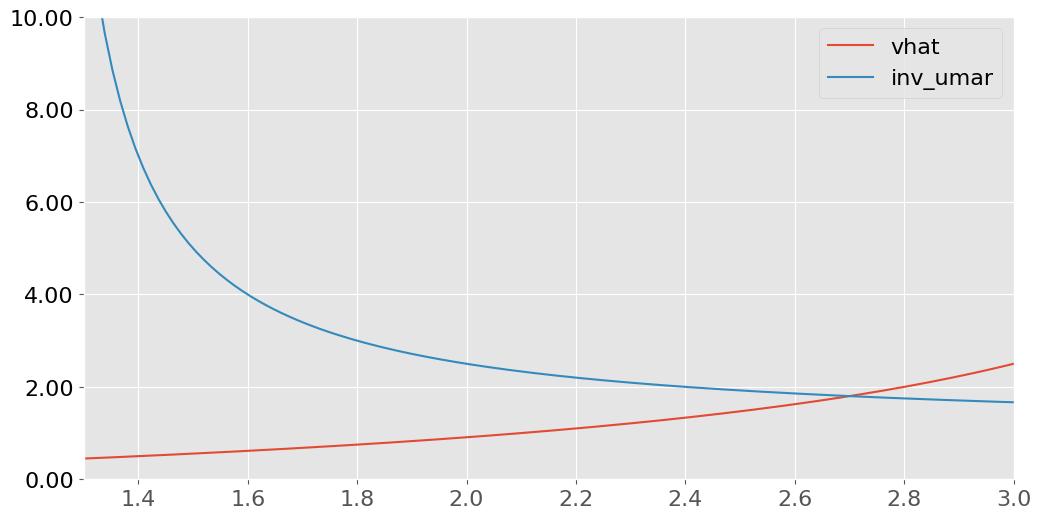

df_demand_linear.head()


,p_mid,p,delta,p_delta,d,d_delta,vhat,inv_umar,diff_vhat_inv_umar,demand_type
0,1.226965,1.220000,0.01397,1.233970,1329.628210,1323.395088,0.412704,45.502062,-45.089358,linear
1,1.240935,1.233970,0.01397,1.247940,1323.395088,1317.161965,0.419373,30.314684,-29.895311,linear
2,1.254905,1.247940,0.01397,1.261910,1317.161965,1310.928842,0.426106,22.855860,-22.429754,linear
3,1.268875,1.261910,0.01397,1.275879,1310.928842,1304.695720,0.432903,18.422805,-17.989902,linear
4,1.282845,1.275879,0.01397,1.289849,1304.695720,1298.462597,0.439765,15.484828,-15.045063,linear


target = 2.7
Closest index: 105


,p_mid,p,delta,p_delta,d,d_delta,vhat,inv_umar,diff_vhat_inv_umar,demand_type
100,2.623961,2.616985,0.01397,2.630955,706.315940,700.082817,1.664931,1.842720,-0.177789,linear
101,2.637930,2.630955,0.01397,2.644925,700.082817,693.849695,1.688764,1.834533,-0.145769,linear
102,2.651900,2.644925,0.01397,2.658894,693.849695,687.616572,1.713027,1.826503,-0.113476,linear
103,2.665870,2.658894,0.01397,2.672864,687.616572,681.383449,1.737733,1.818626,-0.080894,linear
104,2.679840,2.672864,0.01397,2.686834,681.383449,675.150327,1.762892,1.810898,-0.048006,linear
105,2.693810,2.686834,0.01397,2.700804,675.150327,668.917204,1.788518,1.803315,-0.014797,linear
106,2.707780,2.700804,0.01397,2.714774,668.917204,662.684081,1.814624,1.795872,0.018752,linear
107,2.721750,2.714774,0.01397,2.728744,662.684081,656.450959,1.841224,1.788566,0.052658,linear
108,2.735720,2.728744,0.01397,2.742714,656.450959,650.217836,1.868331,1.781393,0.086938,linear
109,2.749690,2.742714,0.01397,2.756683,650.217836,643.984713,1.895960,1.774349,0.121612,linear


In [24]:
# linear demand
N = 200
p = np.linspace(c+.02, 4, N)

demand_type = "linear"
demand_params = {"A": A_linear, "b": b_linear}

df_demand_linear = get_vhat_invumar_df(p, demand_type=demand_type, demand_params=demand_params,c=c, sigma_log=0)

print(f'demand type = {demand_type}')
print(f'demand_params = {demand_params}')

bp.lineplot(df_demand_linear, x="p_mid", y=["vhat", "inv_umar"],
            x_lims=(1.3,3), y_lims=(0,10), figsize=(12,6))


print("df_demand_linear.head()")
display(df_demand_linear.head())
# 1. Find the index label of the closest value
target = 2.7
print(f'target = {target}')
closest_index = (df_demand_linear['p_mid'] - target).abs().idxmin()
print(f'Closest index: {closest_index}')
display(df_demand_linear.iloc[closest_index-5:closest_index+5])



demand type = logit
demand_params = {'A': 1338.5518896756485, 'a': 3.6, 'b': 1.3333333333333335}


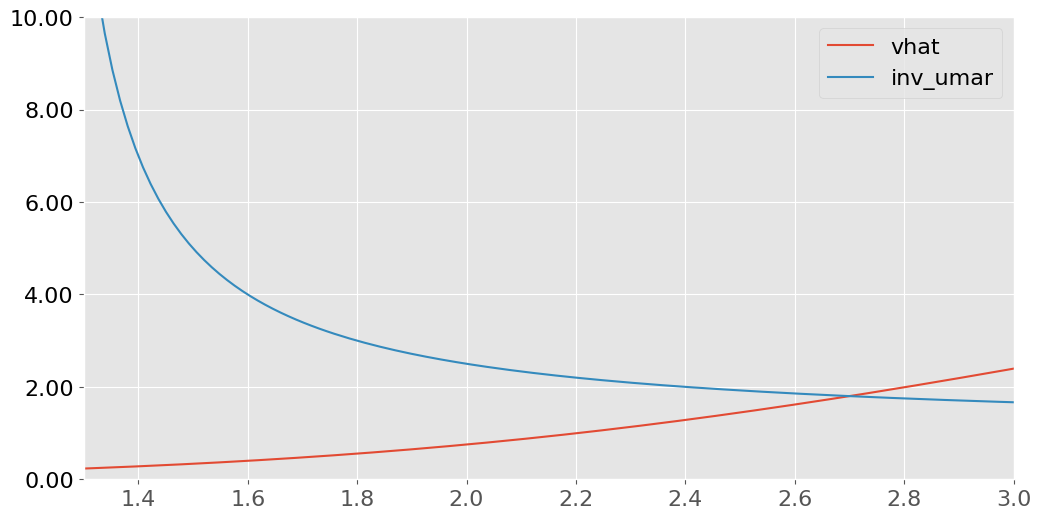

df_demand_logit.head()


,p_mid,p,delta,p_delta,d,d_delta,vhat,inv_umar,diff_vhat_inv_umar,demand_type
0,1.226965,1.220000,0.01397,1.233970,1175.206657,1172.516537,0.201279,45.502062,-45.300783,logit
1,1.240935,1.233970,0.01397,1.247940,1172.516537,1169.788475,0.206919,30.314684,-30.107765,logit
2,1.254905,1.247940,0.01397,1.261910,1169.788475,1167.022148,0.212682,22.855860,-22.643177,logit
3,1.268875,1.261910,0.01397,1.275879,1167.022148,1164.217233,0.218571,18.422805,-18.204234,logit
4,1.282845,1.275879,0.01397,1.289849,1164.217233,1161.373415,0.224586,15.484828,-15.260242,logit


Target price: 2.7
Closest index: 105


,p_mid,p,delta,p_delta,d,d_delta,vhat,inv_umar,diff_vhat_inv_umar,demand_type
100,2.623961,2.616985,0.01397,2.630955,706.278170,700.061078,1.660719,1.842720,-0.182001,logit
101,2.637930,2.630955,0.01397,2.644925,700.061078,693.838658,1.685904,1.834533,-0.148629,logit
102,2.651900,2.644925,0.01397,2.658894,693.838658,687.611982,1.711275,1.826503,-0.115228,logit
103,2.665870,2.658894,0.01397,2.672864,687.611982,681.382129,1.736829,1.818626,-0.081797,logit
104,2.679840,2.672864,0.01397,2.686834,681.382129,675.150176,1.762563,1.810898,-0.048335,logit
105,2.693810,2.686834,0.01397,2.700804,675.150176,668.917204,1.788475,1.803315,-0.014840,logit
106,2.707780,2.700804,0.01397,2.714774,668.917204,662.684294,1.814562,1.795872,0.018690,logit
107,2.721750,2.714774,0.01397,2.728744,662.684294,656.452528,1.840821,1.788566,0.052255,logit
108,2.735720,2.728744,0.01397,2.742714,656.452528,650.222985,1.867248,1.781393,0.085856,logit
109,2.749690,2.742714,0.01397,2.756683,650.222985,643.996745,1.893842,1.774349,0.119493,logit


In [25]:
# logit demand
N = 200
p = np.linspace(c+.02, 4, N)

demand_type = "logit"
demand_params = {"A": A_logit,"a": a_logit,  "b": b_logit}

df_demand_logit = get_vhat_invumar_df(p, demand_type=demand_type, demand_params=demand_params, c=c,sigma_log=0)

print(f'demand type = {demand_type}')
print(f'demand_params = {demand_params}')

bp.lineplot(df_demand_logit, x="p_mid", y=["vhat", "inv_umar"],
            x_lims=(1.3,3), y_lims=(0,10), figsize=(12,6))

print("df_demand_logit.head()")
display(df_demand_logit.head())

# 1. Find the index label of the closest value
target = 2.7
print(f'Target price: {target}')
closest_index = (df_demand_logit['p_mid'] - target).abs().idxmin()
print(f'Closest index: {closest_index}')
display(df_demand_logit.iloc[closest_index-5:closest_index+5])

## Optimum Price and Profit Calculation

```Python
    p_grid = np.linspace( prices.min(),prices.max(),  500,)
    profit_hat = (p_grid - c) * dhat_grid - F
    i_opt = np.argmax(profit_hat)
    p_opt_hat = p_grid[i_opt]
    d_opt_hat = dhat_grid[i_opt]
    profit_opt_hat = profit_hat[i_opt]

```

Because F is constant across prices, it does not change the estimated optimal price, though it does change the reported profit.

## Inference with Context Features, x

For inference, the context must be held fixed at the conditions for which you want to choose the price ... they are not held constant during training.

Holding x (features) constant during price optimization is not a weakness. It means: Given today’s traffic, competitor price, promotion status, and seasonality, which price maximizes expected profit?

A common regression heuristic is at least: 10–20 observations per effective parameter. For example, suppose you have:
* 6 spline basis coefficients for price,
* 4 context variables,
* 1 intercept.

That is roughly 11 parameters, suggesting approximately:

110–220 observations.

For Example
```Python
    x_current = np.array([
        11000,  # traffic
        2.80,   # competitor price
        0,      # promotion
        0,      # weekend
    ])
```

**Repeat the context for every observation**

```Python
    x_grid = np.tile(x_current, (len(p_grid), 1))

    dhat_grid = dhat_model(
        p_new=p_grid,
        x_new=x_grid,
    )
```


### Weighted Repeated Prices

The weights, for repeated measurements are used by the regression in attempt to minimize weight loss for the repeated demands.

$$
\sum_i w_i (y_i - y_i^2)
$$

where, here $y_i = \log \, d_i$

So if one aggregated point has weight 3 and another has weight 1, the optimizer is willing to tolerate three times more error at the second point than at the first.

In our case, we are using sqrt(n). The important point is that there is no fundamental reason to use $\sqrt n $ It is a heuristic.

The reasoning is:

* Repeated observations at the same price are more reliable than a single observation.
* Therefore, their aggregated point should influence the fit more.
* But if you use weight = n, a heavily sampled price can dominate the regression.
* So using weight = $sqrt (n)$ gives repeated prices more influence, but with diminishing returns.


Don't confuse this with geometric mean in linear-space, which translates to arithmetic mean in log-scale

Example:

Suppose an offered price is repeated three times, n = 3

$$
d = (800, 1000, 1200 )
$$

$$
d_{geo} = (800, 1000, 1200)^{1/3} \approx 986
$$

Then $\sqrt(counts) $ gives the aggregated point weight. Note that we have chosen the square root as a comprise to the full n-th weighting. It means that a repeated sample of n-times gets less weight than a fully weighted sample with n =1 ( not repeated).
$$
w = \sqrt(3) = 1.73
$$
So the point has more influence than one observation, but less than treating all three observations as three fully separate regression points.


### Elasticity Estimate vhat(p)


Log Linear Estimator
$$
\hat v(p) = - \frac{d \, log  \, \hat d(p)} {d \, log \, p} = - \hat \beta_1
$$

Log Quadratic Estimator
$$
\hat v(p) = - \left ( \hat \beta_1 \, + \hat \beta_2 \, log (p) \right )
$$



## Demand Estimatation

In [30]:
from demand_price_estimation import vhat_calculator, select_demand_model, select_demand_model, aggregate_price_demand

### Test

* Constant Elasticity convergence on optimum struggles ... test_case_1, 2
* 

In [27]:
# tests

test_case = "test_case_2"

if test_case == "test_case_1":
    # this test case resulted in log-quadratic and did not select optimum price correctly, 4.0
    # sigma_log ~= 0.2
    demand_type = "constant_elasticity"
    demand_params = {'A': 4000, 'v': 1.8}
    ridge_cv = True
    p_history = [2.0, 2.0, 2.0, 2.5, 2.5, 2.5, 3.0, 3.0, 3.0, 3.5, 3.5, 3.5, 4.0, 4.0, 4.0, 3.08, 4.0, 4.0, 4.0, 4.0]
    d_history = [1079.2, 1116.2, 991.1, 611.1, 979.0, 869.5, 569.4, 566.5, 456.2, 344.4, 466.7, 491.9, 353.4, 413.4, 328.2, 450.0, 374.6, 325.9, 450.0, 397.2]
    
elif test_case == "test_case_2":
    # this test case resulted in log-quadratic and did not select optimum price correctly, 4.0
    # sigma_log ~= 0.2
    demand_type ="constant_elasticity"
    demand_params = {'A': 4000, 'v': 1.8}
    ridge_cv = True
    p_history = [2.0, 2.0, 2.5, 2.5, 3.0, 3.0, 3.5, 3.5, 4.0, 4.0, 3.0, 3.39, 2.98, 3.65, 3.11, 3.45, 2.89, 3.54, 3.04, 3.29]
    d_history = [866.8, 1333.4, 1202.4, 663.8, 589.9, 697.1, 544.0, 493.3, 345.2, 487.5, 664.4, 431.6, 543.9, 426.3, 612.2, 324.9, 527.3, 337.9, 485.1, 791.3]

print(f"test_case = {test_case}")
# Aggregate repeated prices
p_fit, d_fit, counts = aggregate_price_demand(  p=p_history,   d=d_history,)
sample_weights = np.sqrt(counts)

# Grid used to maximize estimated profit
p_grid = np.maximum( np.linspace(price_min, price_max, 100),  c + 0.02,)

# fit model
candidate_model_types = [ "linear", "log_level", "log_log", "log_quadratic"] # model types

dhat_model, model_info, selected_model_type,  model_diagnostics = select_demand_model(
    p=p_fit, d=d_fit, candidate_model_types=candidate_model_types, price_min=price_min,
    price_max=price_max, c=c, F=F,sample_weights=sample_weights,ridge_cv=True,)


#dhat_model, model_info,  selected_model_type,model_fit_errors = select_demand_model(
#            p=p_fit, d=d_fit, candidate_model_types=candidate_model_types, sample_weights=sample_weights,  ridge_cv=ridge_cv, )

# grids
dhat_grid = dhat_model(p_grid)
d_grid_hat = np.asarray(  dhat_model(p_grid),  dtype=float,)
profit_grid_hat = ( (p_grid - c) * d_grid_hat - F)

# optimums
i_opt = int( np.argmax(profit_grid_hat) )
p_opt_hat = round(p_grid[i_opt],2)
d_opt_hat = round(d_grid_hat[i_opt],1)
profit_opt_hat = round(profit_grid_hat[i_opt],2)
vhat_opt_i = round( float( np.asarray( vhat_calculator( model_info=model_info, p=p_opt_hat, ) ).reshape(-1)[0] ), 2)
inv_umar_i = round( p_opt_hat  / (p_opt_hat - c),  2,) # inverse unit margin
p_opt_vhat_i = round(  c   * vhat_opt_i   / (vhat_opt_i - 1.0), 2,  )

# print resutls

print(f'model_fit_errors (weighted RMSE) = {model_diagnostics[selected_model_type]["fit_error"]}')
print(f"Selected model type: {selected_model_type}")
print(f'p_opt_hat = {p_opt_hat}')
print(f'd_opt_hat = {d_opt_hat}')
print(f'profit_opt_hat = {profit_opt_hat}')


test_case = test_case_2
model_fit_errors (weighted RMSE) = 0.18926620287440965
Selected model type: log_log
p_opt_hat = 3.54
d_opt_hat = 455.3
profit_opt_hat = 1057.39


In [28]:
# demand calculation
print(f'dhat_grid = {dhat_grid}')

dhat_grid = [1079.40623233 1063.09408829 1047.18711342 1031.6713802  1016.53357013
 1001.76094146  987.34129903  973.26296583  959.51475643  946.08595188
  932.96627621  920.14587422  907.61529068  895.36545064  883.38764092
  871.67349266  860.21496484  849.00432871  838.03415315  827.29729073
  816.78686462  806.49625619  796.41909326  786.54923896  776.88078124
  767.40802286  758.12547195  749.02783302  740.10999848  731.36704053
  722.79420351  714.38689659  706.14068688  698.05129281  690.11457786
  682.32654465  674.68332923  667.18119567  659.81653096  652.58584005
  645.48574123  638.51296165  631.66433306  624.93678777  618.32735478
  611.83315608  605.4514031   599.17939339  593.01450732  586.95420506
  580.99602361  575.13757397  569.37653848  563.71066817  558.13778035
  552.65575622  547.26253858  541.95612968  536.73458913  531.59603191
  526.53862642  521.56059268  516.66020054  511.835768    507.08565957
  502.40828472  497.80209638  493.26558949  488.79729961  484.395

In [29]:
# profit calculation
print(f'dhat_grid*(p_grid - c) - F = {dhat_grid*(p_grid - c) - F}')

dhat_grid*(p_grid - c) - F = [ 857.52498587  865.95191888  874.06028118  881.86264235  889.37098298
  896.59672706  903.55077244  910.24351935  916.68489709  922.88438912
  928.85105656  934.59356031  940.1201818   945.43884249  950.55712228
  955.48227675  960.22125343  964.78070718  969.16701458  973.38628761
  977.44438649  981.34693182  985.09931605  988.70671432  992.17409468
  995.50622781  998.70769615 1001.7829026  1004.73607873 1007.57129253
 1010.29245584 1012.9033313  1015.40753901 1017.80856278 1020.10975617
 1022.3143481  1024.42544827 1026.44605229 1028.37904651 1030.22721268
 1031.99323236 1033.67969109 1035.28908237 1036.82381151 1038.28619919
 1039.67848493 1041.00283042 1042.26132257 1043.45597658 1044.58873875
 1045.66148919 1046.67604448 1047.63416009 1048.53753278 1049.38780285
 1050.18655633 1050.93532703 1051.63559852 1052.28880605 1052.89633831
 1053.45953922 1053.97970957 1054.45810858 1054.89595549 1055.29443093
 1055.65467842 1055.97780561 1056.26488564 1056.